In [17]:
!pip install tensorflow

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [19]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [20]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [21]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


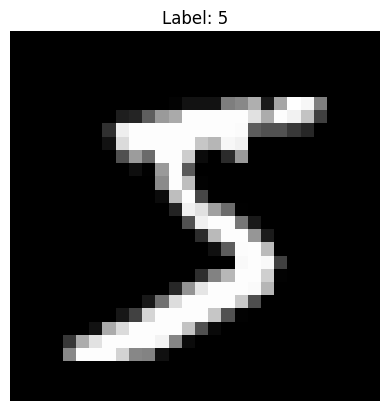

In [22]:
plt.imshow(X_train[0], cmap="gray")

plt.title(f"Label: {y_train[0]}")

plt.axis("off")

plt.show()

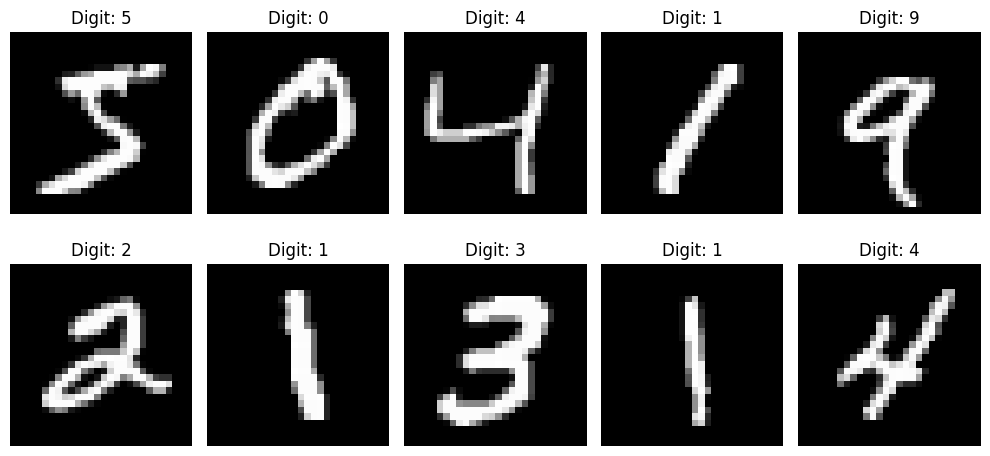

In [23]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(f"Digit: {y_train[i]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [25]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [26]:
X_train = X_train.reshape(-1, 28, 28, 1)

X_test = X_test.reshape(-1, 28, 28, 1)

In [27]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [28]:
model = Sequential([

    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 68s 79ms/step - accuracy: 0.9522 - loss: 0.1584 - val_accuracy: 0.9848 - val_loss: 0.0542
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.9858 - loss: 0.0457 - val_accuracy: 0.9887 - val_loss: 0.0401
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 64s 76ms/step - accuracy: 0.9898 - loss: 0.0314 - val_accuracy: 0.9898 - val_loss: 0.0333


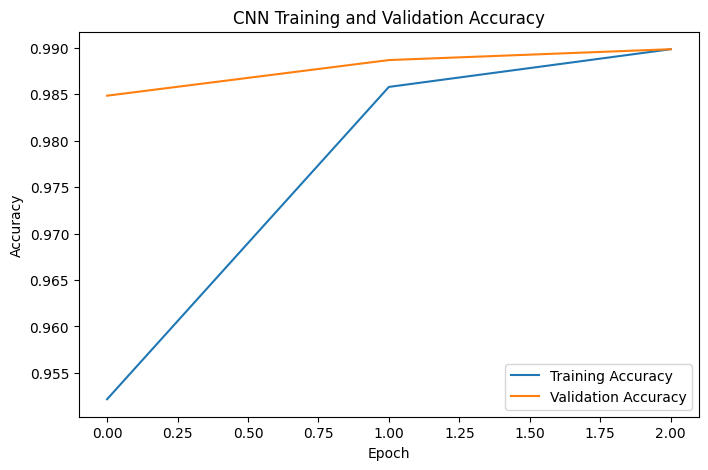

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("CNN Training and Validation Accuracy")

plt.legend()

plt.show()

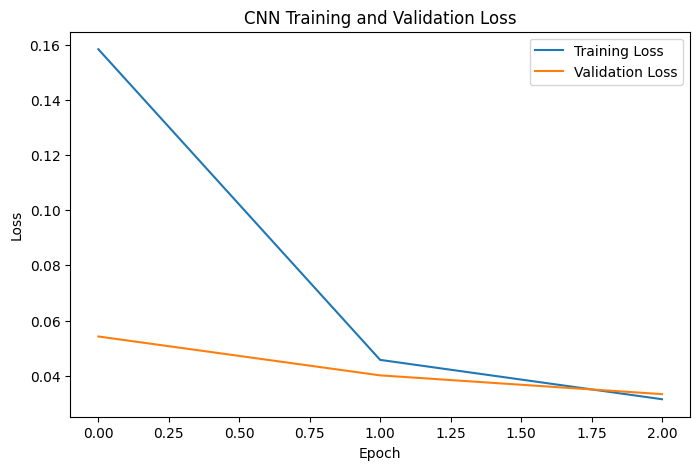

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("CNN Training and Validation Loss")

plt.legend()

plt.show()

In [34]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9903 - loss: 0.0283
Test Loss: 0.02829786017537117
Test Accuracy: 0.9902999997138977


In [35]:
predictions = model.predict(X_test)

print(predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
(10000, 10)


In [36]:
predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels[:10])

[7 2 1 0 4 1 4 9 5 9]


In [37]:
for i in range(10):

    print(
        "Actual:",
        y_test[i],
        "Predicted:",
        predicted_labels[i]
    )

Actual: 7 Predicted: 7
Actual: 2 Predicted: 2
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 4 Predicted: 4
Actual: 1 Predicted: 1
Actual: 4 Predicted: 4
Actual: 9 Predicted: 9
Actual: 5 Predicted: 5
Actual: 9 Predicted: 9


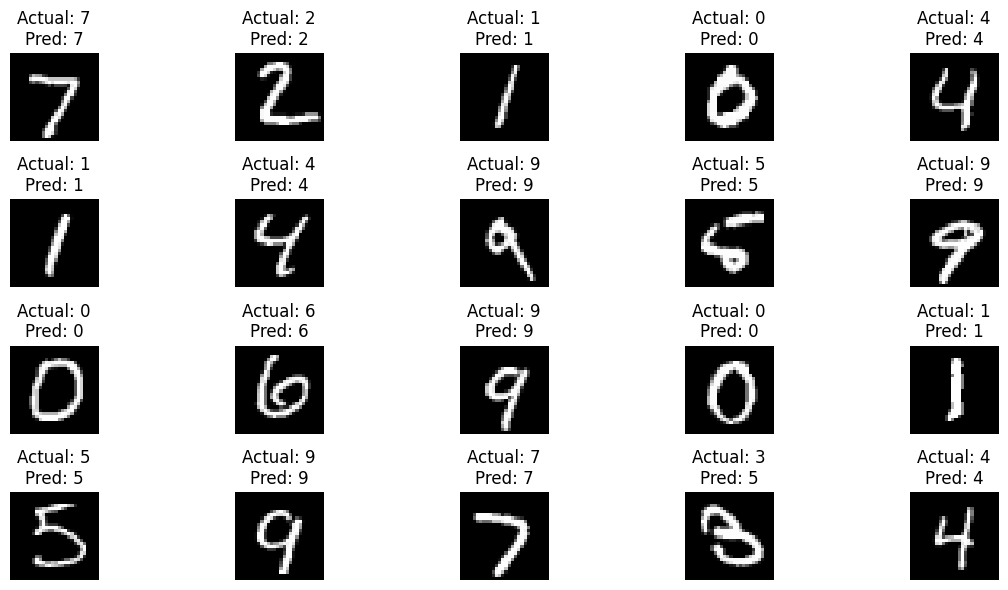

In [38]:
plt.figure(figsize=(12, 6))

for i in range(20):

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]}\nPred: {predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predicted_labels
)

print(cm)

[[ 975    0    1    1    0    0    1    0    1    1]
 [   0 1131    1    0    0    1    0    1    1    0]
 [   1    1 1020    4    0    0    0    3    3    0]
 [   0    0    0 1000    0    8    0    0    2    0]
 [   0    0    0    0  980    0    0    0    0    2]
 [   0    0    0    1    0  890    1    0    0    0]
 [   3    3    1    0    1    5  945    0    0    0]
 [   0    0    5    1    1    0    0 1015    1    5]
 [   2    0    1    2    0    1    0    2  963    3]
 [   0    1    0    1    9    6    0    5    3  984]]


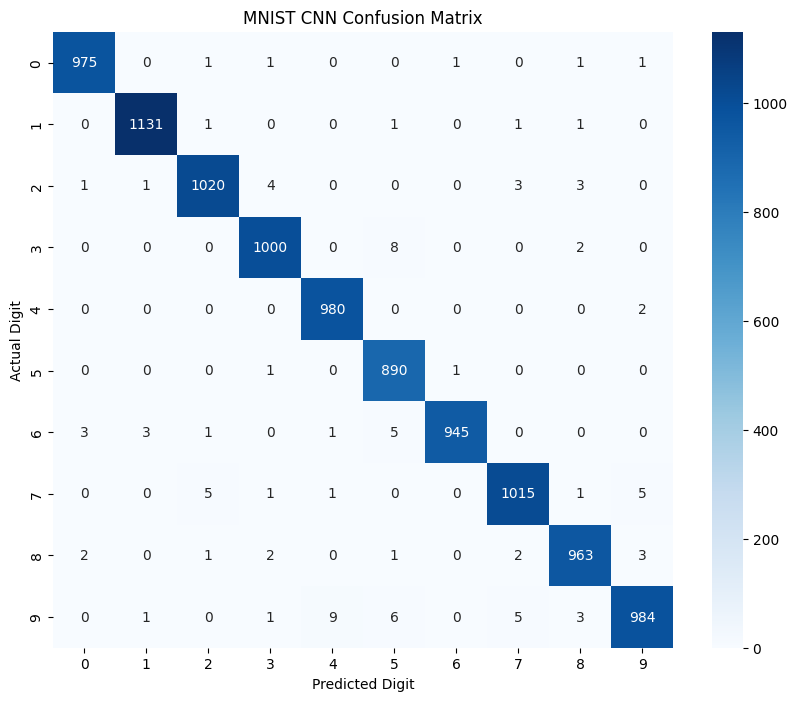

In [40]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Digit")

plt.ylabel("Actual Digit")

plt.title("MNIST CNN Confusion Matrix")

plt.show()

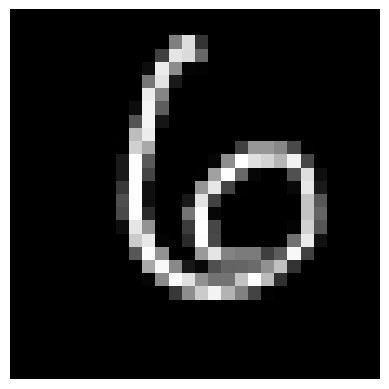

In [41]:
index = 100

image = X_test[index]

plt.imshow(
    image.reshape(28, 28),
    cmap="gray"
)

plt.axis("off")

plt.show()